# A machine under uncertainty, against hiring one in

A single net present value is a point estimate built from numbers nobody knows.
This notebook takes the same appraisal and asks four questions a point estimate
cannot answer:

1. How wide is the answer, and how often does the ranking actually hold?
2. Which input does the answer turn on?
3. At what value of that input does the decision change?
4. Does the choice survive the states of the world worth naming?

In [1]:
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from simplyinvest import (
    Alternative,
    Amount,
    Case,
    CashFlowSeries,
    Component,
    Context,
    GeometricDecline,
    Recurring,
    Role,
    Term,
    Timeline,
)
from simplyinvest.financing import CashPurchase
from simplyinvest.money import Quantity
from simplyinvest.report import (
    differential_chart,
    distribution_chart,
    draws_frame,
    ranking_frame,
    scenario_chart,
    scenario_frame,
    simulation_frame,
    sweep_chart,
    tornado_chart,
    tornado_frame,
)
from simplyinvest.uncertain import (
    LogNormal,
    Normal,
    Scenario,
    one_way,
    run_scenarios,
    simulate,
    switch_point,
    tornado,
    uncertain,
)

BUY = "#2b6cb0"
HIRE = "#c05621"

# Every chart in simplyinvest.report takes its colours from the active cycle,
# so the whole notebook is styled once, here.
plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.5),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.prop_cycle": plt.cycler(color=[BUY, HIRE]),
    }
)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## The model

Identical to the deterministic example, except that three numbers are wrapped in
`uncertain(...)`. A marked number is a `float` subclass, so it keeps working
everywhere a float does — the model does not change shape to accommodate it.

In [2]:
@dataclass(frozen=True)
class Machine:
    """A capital asset that loses value with age."""

    name: str
    price: Quantity
    upkeep: Quantity = 0.0
    age_at_acquisition: Term = Term.ZERO
    economic_life: Term | None = None

    @property
    def capital_cost(self) -> Amount:
        return Amount.paid(self.price)

    @property
    def setup_cost(self) -> Amount:
        return Amount.zero()

    def residual_value(self, *, held: Term) -> Amount:
        return Amount.received(
            GeometricDecline(0.18).value_after(
                self.price, held=held, age_at_acquisition=self.age_at_acquisition
            )
        )


@dataclass(frozen=True)
class Upkeep:
    """Servicing the machine, monthly."""

    cost: Quantity = 0.0
    label: Component = field(default_factory=lambda: Component(Role.OPERATING, "upkeep"))

    def flows(self, ctx: Context) -> CashFlowSeries:
        return CashFlowSeries.of(
            Recurring(Amount.paid(self.cost), label=self.label, description="Upkeep")
        )

    def constraints(self, ctx: Context) -> tuple[str, ...]:
        return ()

    @property
    def supports_batch(self) -> bool:
        return True


@dataclass(frozen=True)
class Hire:
    """Paying a monthly rate for the use of a machine, owning nothing."""

    rate: Quantity = 0.0

    def flows(self, ctx: Context) -> CashFlowSeries:
        return CashFlowSeries.of(
            Recurring(
                Amount.paid(self.rate),
                label=Component(Role.OPERATING, "hire"),
                description="Machine hire",
            )
        )

    def constraints(self, ctx: Context) -> tuple[str, ...]:
        return ("The machine is never owned, so nothing is left at the end.",)

    @property
    def supports_batch(self) -> bool:
        return True

In [3]:
mill = Machine(
    "CNC mill",
    price=uncertain(86_000.0, "price", LogNormal.from_mean_cv(86_000.0, 0.09)),
    upkeep=uncertain(420.0, "upkeep", Normal(420.0, 70.0)),
)

case = Case(
    alternatives=(
        Alternative("Buy", sources=(CashPurchase().bind(mill), Upkeep(mill.upkeep))),
        Alternative(
            "Hire",
            sources=(Hire(uncertain(1_450.0, "hire_rate", Normal(1_450.0, 110.0))),),
        ),
    ),
    timeline=Timeline(Term.of_years(8), rate=0.05),
)

display(ranking_frame(case.run()))

,npv,pv_of_costs,eac,irr,payback_months,discounted_payback_months,profitability_index
alternative,,,,,,,
Buy,"-107,415.94","119,030.24","18,416.58",-0.31,None,None,0.10
Hire,"-115,014.41","115,014.41","17,795.24",NaN,None,None,0.00


## 1. What the single answer hides

`simulate` walks the case, finds every marked number, draws it, and resolves the
whole comparison once per trial. Where a parameter appears at more than one
address — the mill's price is copied into the purchase that was bound to it —
every address moves together.

Because nothing here rebuilds its stream from the draw, all 20,000 trials are
resolved in a single vectorised pass.

In [4]:
run = simulate(case, n=20_000, seed=20260930)

display(simulation_frame(run))
print(run.verdict())
print(f"resolved in one pass: {run.batched}")

# The draws themselves, one row per trial.
display(draws_frame(run).head())

,expected,p5,p25,p50,p75,p95,p_positive,value_at_risk,win_share,regret
alternative,,,,,,,,,,
Buy,"-107,323.81","-121,918.12","-113,085.08","-107,116.14","-101,427.91","-93,350.81",0.00,"-121,918.12",0.73,"2,035.83"
Hire,"-115,024.27","-129,277.73","-120,855.14","-115,075.33","-109,187.91","-100,841.23",0.00,"-129,277.73",0.27,"9,736.29"


Buy has the higher expected value, and beats Hire in 73.3% of 20,000 trials (±0.3%).
resolved in one pass: True


,hire_rate,price,upkeep,Buy,Hire
trial,,,,,
0,"1,427.05","92,943.10",326.89,"-106,013.27","-113,194.06"
1,"1,412.50","87,972.25",329.67,"-101,950.10","-112,040.08"
2,"1,393.27","75,884.49",526.45,"-107,143.62","-110,514.20"
3,"1,401.50","83,432.10",462.98,"-108,612.72","-111,167.71"
4,"1,339.36","68,142.30",279.58,"-80,890.96","-106,238.71"


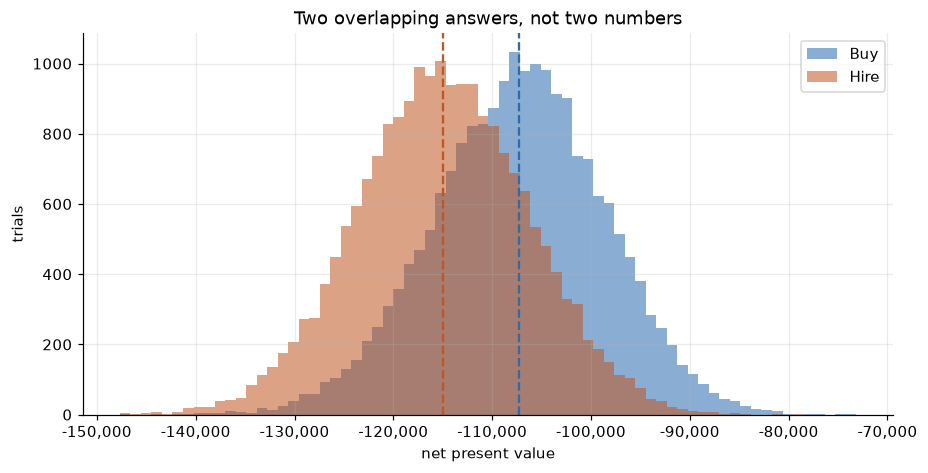

In [5]:
fig, ax = plt.subplots()
distribution_chart(run, ax=ax)
ax.set_title("Two overlapping answers, not two numbers")
plt.show()

The two distributions overlap, which is the whole point: the deterministic table
said *Buy* and stopped. The differential stream says how often that holds.

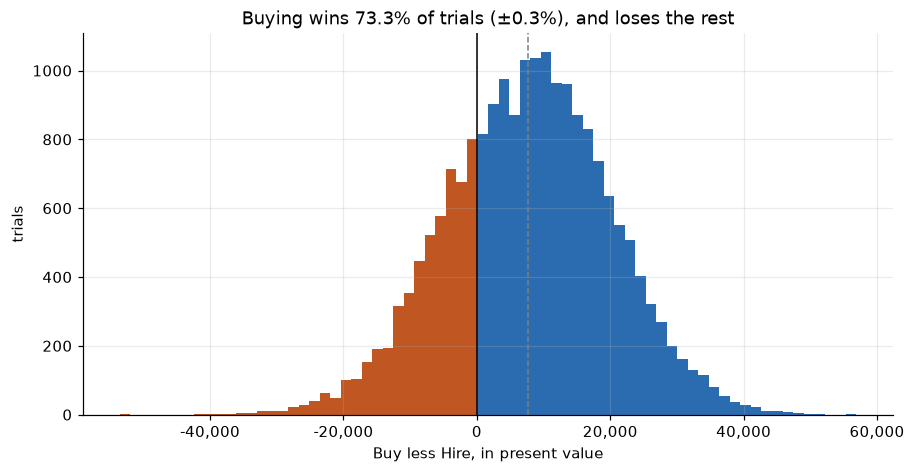

In [6]:
share = run.probability("Buy", "Hire")

fig, ax = plt.subplots()
differential_chart(run, "Buy", "Hire", ax=ax)
ax.set_title(
    f"Buying wins {share:.1%} of trials "
    f"(±{run.standard_error('Buy', 'Hire'):.1%}), and loses the rest"
)
plt.show()

## 2. What the answer turns on

A tornado moves one parameter at a time between its 10th and 90th percentiles
and measures the swing. A parameter belonging to the other alternative shows a
swing of zero, which is a useful thing to be able to see rather than assume.

,low,high,swing
parameter,,,
price,"-99,093.08","-116,121.15","17,028.07"
upkeep,"-100,300.23","-114,531.66","14,231.42"
hire_rate,"-107,415.94","-107,415.94",0.00


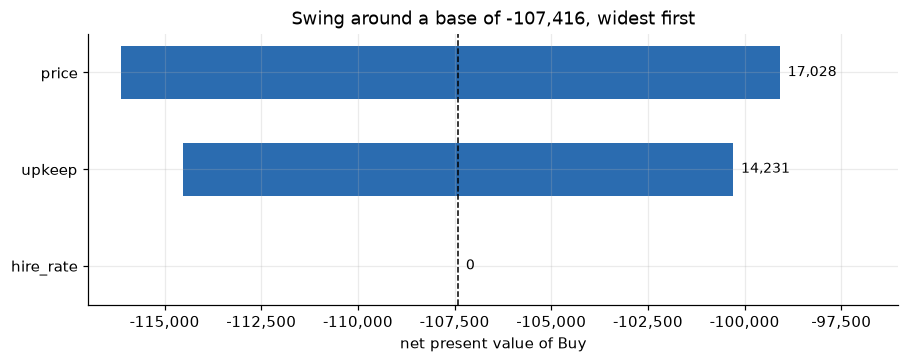

In [7]:
bars = tornado(case, on="Buy")
display(tornado_frame(bars))

fig, ax = plt.subplots(figsize=(9.5, 3.2))
tornado_chart(bars, ax=ax)
ax.set_title(f"Swing around a base of {bars.base:,.0f}, widest first")
plt.show()

## 3. Where the decision changes

The spread is not the decision. What matters is whether the ranking turns inside
the range the inputs plausibly cover. `switch_point` brackets the differential
present value and names which alternative leads on each side, so the number
cannot be read the wrong way round.

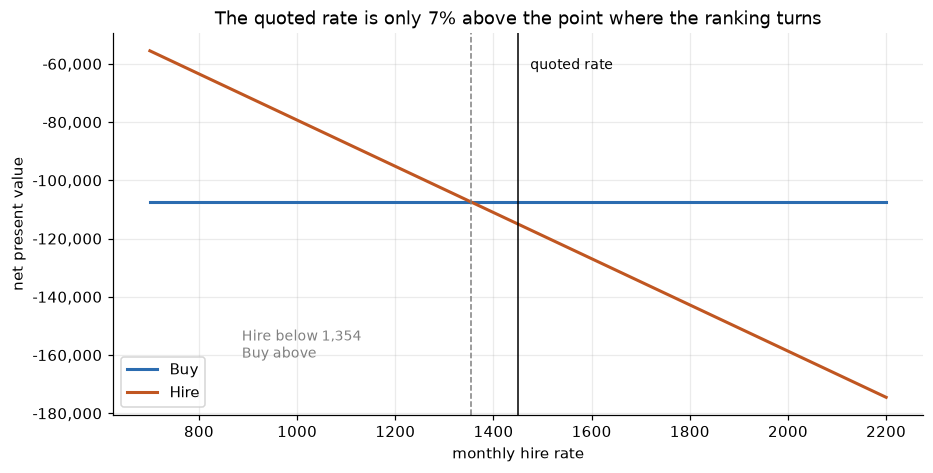

Hire leads while hire_rate is below 1,354.21, Buy above it


In [8]:
rates = np.linspace(700.0, 2_200.0, 61)
swept = one_way(case, "hire_rate", rates)
turn = switch_point(case, "hire_rate", better="Hire", worse="Buy", bracket=(200.0, 4_000.0))

fig, ax = plt.subplots()
sweep_chart(swept, switch=turn, ax=ax)

quoted = 1_450.0
if turn is not None:
    ax.annotate(
        f"{turn.below} below {turn.value:,.0f}\n{turn.above} above",
        xy=(turn.value, swept.npv.min()),
        xytext=(-150, 26),
        textcoords="offset points",
        fontsize=9,
        color="grey",
    )
    ax.set_title(
        f"The quoted rate is only {quoted / turn.value - 1:.0%} above the point "
        f"where the ranking turns"
    )

ax.axvline(quoted, color="black", linewidth=1)
ax.annotate(
    "quoted rate",
    xy=(quoted, swept.npv.max()),
    xytext=(8, -12),
    textcoords="offset points",
    fontsize=9,
)
ax.set_xlabel("monthly hire rate")
ax.legend(loc="lower left")
plt.show()

print(turn)

## 4. Does the choice survive the states of the world?

Scenarios are not draws. They are named combinations someone is prepared to
defend. Here the verdict is blunt: either change on its own is enough to reverse
the ranking, which is the same fragility the switch point already showed.

In [9]:
table = run_scenarios(
    case,
    [
        Scenario("As declared", {}),
        Scenario("Dear machine", {"price": 110_000.0}),
        Scenario("Heavy upkeep", {"upkeep": 700.0}),
        Scenario("Both", {"price": 110_000.0, "upkeep": 700.0}),
    ],
)
display(scenario_frame(table))
print(table.verdict())

,Buy,Hire,best
scenario,,,
As declared,"-107,415.94","-115,014.41",Buy
Dear machine,"-128,095.41","-115,014.41",Hire
Heavy upkeep,"-129,625.62","-115,014.41",Hire
Both,"-150,305.09","-115,014.41",Hire


The choice depends on which scenario holds — As declared: Buy, Dear machine: Hire, Heavy upkeep: Hire, Both: Hire.


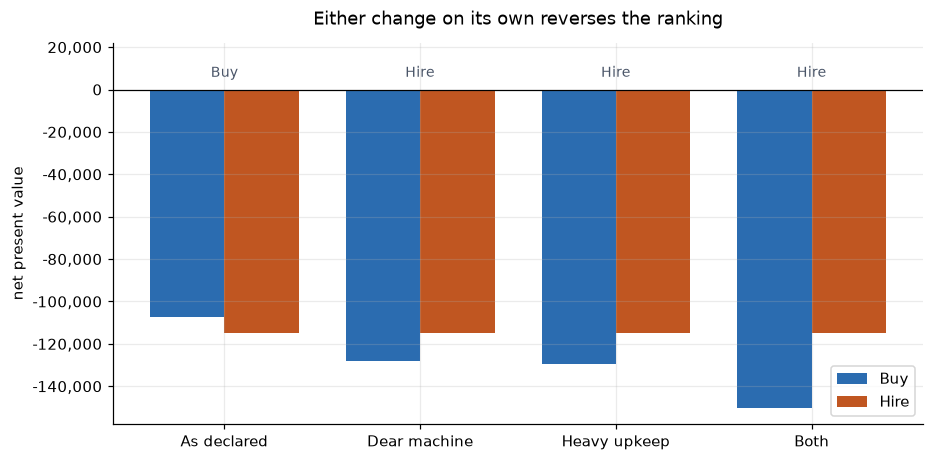

In [10]:
fig, ax = plt.subplots()
scenario_chart(table, ax=ax)

ax.set_ylim(top=22_000.0)
for row, scenario in enumerate(table.scenarios):
    ax.text(row, 6_000.0, table.winner_in(scenario), ha="center", fontsize=9, color="#4a5568")

ax.set_title("Either change on its own reverses the ranking", pad=12)
ax.legend(loc="lower right")
plt.show()

## What this does not claim

Every distribution here was asserted, not measured. The value of the exercise is
not the 5th percentile — it is that the ranking turns at a hire rate the market
could plausibly offer, and that two defensible changes taken together reverse it.

A `switch_point` and a `tornado` are cheap and say more than a confidence
interval. The simulation is what tells you whether to trust either — here, that
a 73% win rate rests on a hire rate only 7% away from turning the decision.